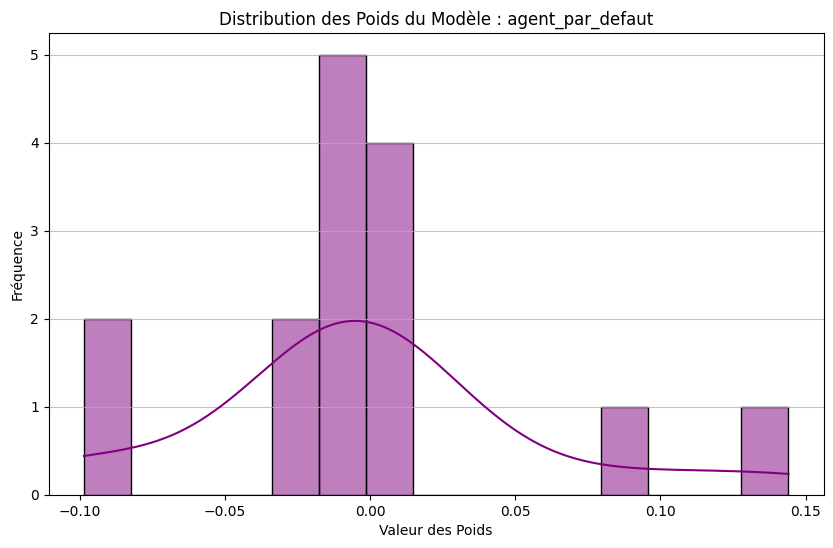

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

AGENT_JSON = "AgentsIA/agent_5_-_5_entrees_sans_filtre.json"

def visualiser_poids():
    """Charge les poids de l'agent JSON et les affiche dans un histogramme."""
    try:
        with open(AGENT_JSON, 'r') as f:
            agent_info = json.load(f)
    except FileNotFoundError:
        print(f"Erreur: Le fichier agent.json n'a pas été trouvé à '{AGENT_JSON}'.")
        return

    poids = np.array(agent_info.get("poids", []))
    nom_agent = agent_info.get("nom", "Agent_MLP")

    if poids.size == 0:
        print("Aucun poids trouvé dans le fichier JSON. Veuillez entraîner le modèle d'abord.")
        return

    poids_plat = poids.flatten()

    plt.figure(figsize=(10, 6))
    sns.histplot(poids_plat, bins=15, kde=True, color='purple', edgecolor='black')
    
    plt.title(f"Distribution des Poids du Modèle : {nom_agent}")
    plt.xlabel("Valeur des Poids")
    plt.ylabel("Fréquence")
    plt.grid(axis='y', alpha=0.75)
    plt.show() # 

visualiser_poids()

ATTENTION: Erreur de traitement pour pong_data_test_2.csv. [Errno 2] No such file or directory: 'pong_data_test_2.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_3.csv. [Errno 2] No such file or directory: 'pong_data_test_3.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_4.csv. [Errno 2] No such file or directory: 'pong_data_test_4.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_5.csv. [Errno 2] No such file or directory: 'pong_data_test_5.csv'. Ignoré.
ATTENTION: Erreur de traitement pour pong_data_test_6.csv. [Errno 2] No such file or directory: 'pong_data_test_6.csv'. Ignoré.


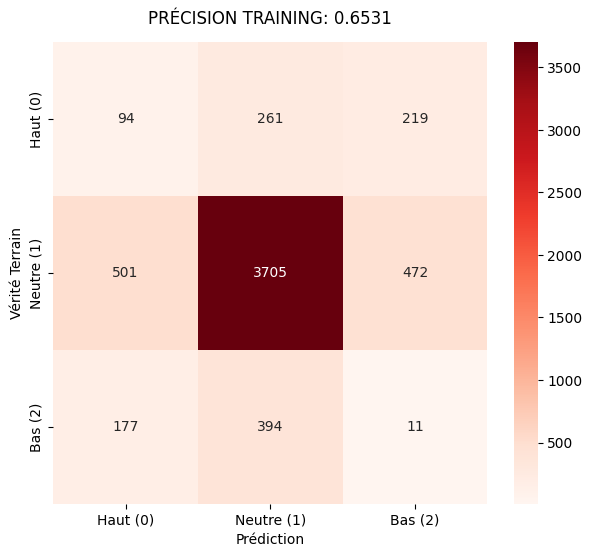

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob 

AGENT_NOM = "agent_5_training_evaluation"
POIDS = np.array([
    [-0.00879281, -0.0985341, -0.0182338, -0.0190199, 0.144118],
    [0.010568, -0.0120714, 0.00817347, -0.00812635, -0.00747582],
    [-0.0107871, 0.0876027, 0.00052795, 0.014273, -0.0976165]
])
BIAIS = np.array([-0.0307193, -0.00298402, -0.0212115])

TRAINING_FILES = [
    "pong_data_test_1.csv", "pong_data_test_2.csv", "pong_data_test_3.csv", 
    "pong_data_test_4.csv", "pong_data_test_5.csv", "pong_data_test_6.csv"
]


def predict_multiclass_perceptron(X, weights, biases):
    """Calcule les scores et retourne l'indice de la classe max (0, 1 ou 2)."""
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_et_concatener_datasets(file_list):
    """Charge et concatène les 6 fichiers de training."""
    all_X = []
    all_Y = []
    
    for chemin_fichier in file_list:
        try:
            df = pd.read_csv(chemin_fichier, header=None)
            X_data = df.iloc[:, [0, 1, 2, 3, 4]].values
            raw_output = df.iloc[:, 6].values
            
            Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
            
            all_X.append(X_data)
            all_Y.append(Y_mapped)
            
        except Exception as e:
            print(f"ATTENTION: Erreur de traitement pour {chemin_fichier}. {e}. Ignoré.")
            
    if not all_X:
        return None, None
        
    return np.concatenate(all_X), np.concatenate(all_Y)


def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la Matrice de Confusion (DESIGN FINAL DEMANDÉ AVEC LABELS D'AXE)."""
    
    labels = [0, 1, 2]
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred) 
    
    plt.figure(figsize=(7, 6))
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Reds', 
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'], 
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']
    )
    
    
    
    plt.xlabel("Prédiction") 
    plt.ylabel("Vérité Terrain")
    
    plt.text(0.5, 1.05, f"PRÉCISION TRAINING: {acc:.4f}", ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    
    plt.show() 



def evaluer_modele_sur_training():
    """Fonction principale pour charger l'agent et évaluer les performances sur le training set."""
    
    X_train, Y_train_true = charger_et_concatener_datasets(TRAINING_FILES)
    if X_train is None:
        return

    Y_train_pred = predict_multiclass_perceptron(X_train, POIDS, BIAIS)
    
    visualiser_matrice_confusion(Y_train_true, Y_train_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele_sur_training()

Fichier de test utilisé : C:\Users\Delta\Desktop\pong_data_session_test_20251214_195704.csv
Évaluation du modèle 'agent' avec 3124 exemples.


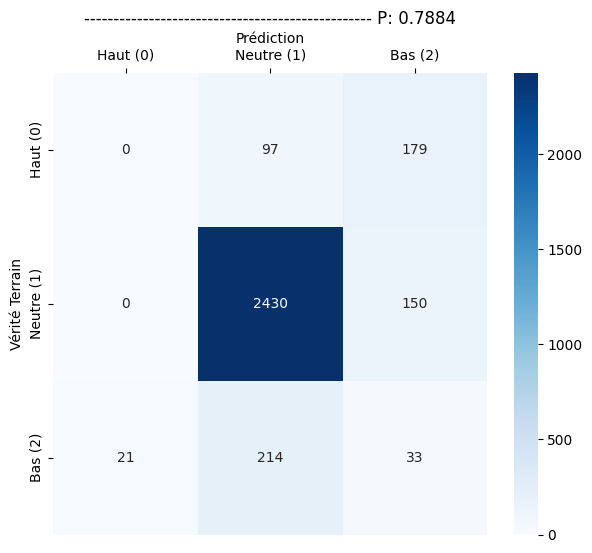

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os
import glob


AGENT_NOM = "agent"
POIDS = np.array([
    [-0.00507369, -0.101397, -0.011833, -0.0100907, 0.142719],
    [0.0140353, -0.00886303, 0.0105133, -0.0017137, -0.00940377],
    [-0.0211495, 0.0877561, -0.00628415, 0.0114415, -0.0972938]
])
BIAIS = np.array([-0.0394376, 0.0038705, -0.0147509])

desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
search_pattern = os.path.join(desktop_path, "pong_data_session_test_*.csv")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    print(f"Erreur : Aucun fichier de session de test trouvé sous '{search_pattern}'")
    exit()

DATASET_CSV = max(list_of_files, key=os.path.getctime)
print(f"Fichier de test utilisé : {DATASET_CSV}")


def predict_multiclass_perceptron(X, weights, biases):
    dot_product = X @ weights.T
    scores = dot_product + biases
    predictions = np.argmax(scores, axis=1)
    return predictions

def charger_dataset(chemin_fichier):
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        X_data = df.iloc[:, [0,1,2,3,4]].values
        raw_output = df.iloc[:,6].values
        Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    labels = [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    plt.figure(figsize=(7,6))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'],   # Prédiction
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']    # Vérité terrain
    )
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

    plt.xlabel("Prédiction")
    plt.ylabel("Vérité Terrain")
    plt.title(f"------------------------------------------------- P: {acc:.4f}")
    plt.show()


def evaluer_modele():
    X, Y_true = charger_dataset(DATASET_CSV)
    if X is None:
        return
    print(f"Évaluation du modèle '{AGENT_NOM}' avec {X.shape[0]} exemples.")
    
    Y_pred = predict_multiclass_perceptron(X, POIDS, BIAIS)
    visualiser_matrice_confusion(Y_true, Y_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele()


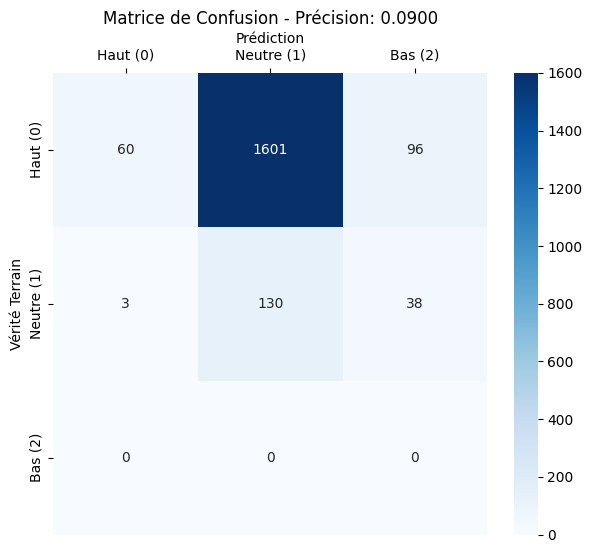

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

labels = [0, 1, 2]  # 0: Haut, 1: Neutre, 2: Bas
cm = confusion_matrix(Y_true, Y_pred, labels=labels)
acc = accuracy_score(Y_true, Y_pred)

plt.figure(figsize=(7,6))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'],   # Prédictions
    yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']    # Vérité terrain
)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.xlabel("Prédiction")
plt.ylabel("Vérité Terrain")
plt.title(f"Matrice de Confusion - Précision: {acc:.4f}")
plt.show()


Évaluation du modèle 'agent_par_defaut' avec 2110 exemples.
Frame 0: Action réelle = 1, Action prédite = 1
Frame 1: Action réelle = 1, Action prédite = 1
Frame 2: Action réelle = 1, Action prédite = 1
Frame 3: Action réelle = 1, Action prédite = 1
Frame 4: Action réelle = 1, Action prédite = 1
Frame 5: Action réelle = 1, Action prédite = 1
Frame 6: Action réelle = 1, Action prédite = 1
Frame 7: Action réelle = 1, Action prédite = 1
Frame 8: Action réelle = 1, Action prédite = 1
Frame 9: Action réelle = 1, Action prédite = 1
Frame 10: Action réelle = 1, Action prédite = 1
Frame 11: Action réelle = 1, Action prédite = 1
Frame 12: Action réelle = 1, Action prédite = 1
Frame 13: Action réelle = 1, Action prédite = 1
Frame 14: Action réelle = 1, Action prédite = 1
Frame 15: Action réelle = 1, Action prédite = 1
Frame 16: Action réelle = 1, Action prédite = 1
Frame 17: Action réelle = 1, Action prédite = 1
Frame 18: Action réelle = 1, Action prédite = 1
Frame 19: Action réelle = 1, Action pr

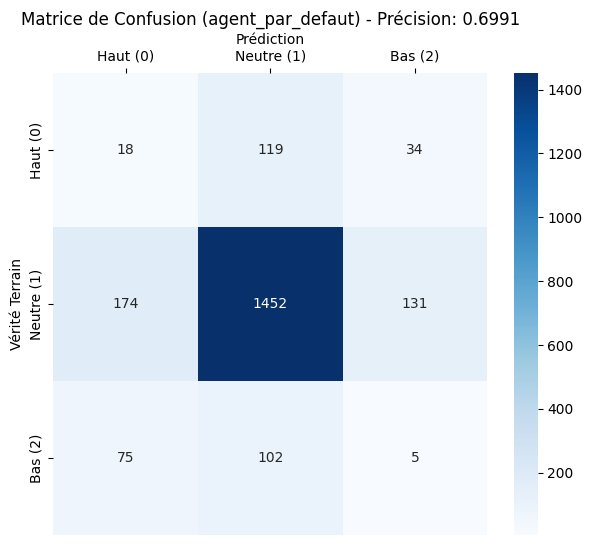

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os

AGENT_NOM = "agent_par_defaut"
POIDS = np.array([
    [-0.00879281, -0.0985341, -0.0182338, -0.0190199, 0.144118],
    [0.010568, -0.0120714, 0.00817347, -0.00812635, -0.00747582],
    [-0.0107871, 0.0876027, 0.00052795, 0.014273, -0.0976165]
])
BIAIS = np.array([-0.0307193, -0.00298402, -0.0212115])

DATASET_CSV = "pong_data_session_PVP_20251214_215305.csv"

if not os.path.exists(DATASET_CSV):
    print(f"Erreur : le fichier '{DATASET_CSV}' n'existe pas.")
    exit()


def predict_multiclass_perceptron(X, weights, biases):
    """Prédit la classe (0,1,2) pour chaque input."""
    scores = X @ weights.T + biases
    return np.argmax(scores, axis=1)

def charger_dataset(chemin_fichier):
    """Charge le CSV et mappe les actions réelles en 0,1,2."""
    try:
        df = pd.read_csv(chemin_fichier, header=None)
        X_data = df.iloc[:, [0,1,2,3,4]].values
        raw_output = df.iloc[:, 6].values
        Y_mapped = np.where(raw_output < -0.5, 2, np.where(raw_output > 0.5, 0, 1))
        return X_data, Y_mapped
    except Exception as e:
        print(f"Erreur lors du chargement du dataset: {e}")
        return None, None

def visualiser_matrice_confusion(y_true, y_pred, nom_agent):
    """Affiche la matrice de confusion avec prédiction en haut et vérité terrain à gauche."""
    labels = [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    plt.figure(figsize=(7,6))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)'],   # Prédiction
        yticklabels=['Haut (0)', 'Neutre (1)', 'Bas (2)']    # Vérité terrain
    )
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

    plt.xlabel("Prédiction")
    plt.ylabel("Vérité Terrain")
    plt.title(f"Matrice de Confusion ({nom_agent}) - Précision: {acc:.4f}")
    plt.show()


def evaluer_modele():
    X_test, Y_true = charger_dataset(DATASET_CSV)
    if X_test is None:
        return

    print(f"Évaluation du modèle '{AGENT_NOM}' avec {X_test.shape[0]} exemples.")

    # Prédictions de l'agent
    Y_pred = predict_multiclass_perceptron(X_test, POIDS, BIAIS)

    # Affichage ligne par ligne
    for i in range(len(Y_pred)):
        print(f"Frame {i}: Action réelle = {Y_true[i]}, Action prédite = {Y_pred[i]}")

    # Matrice de confusion
    visualiser_matrice_confusion(Y_true, Y_pred, AGENT_NOM)

if __name__ == "__main__":
    evaluer_modele()


In [ ]:
import numpy as np
import pandas as pd

DATASET_CSV = "pong_data_session_PVP_20251214_215305.csv"
df = pd.read_csv(DATASET_CSV, header=None)

X_test = df.iloc[:, [0,1,2,3,4]].values
Y_true = df.iloc[:, 6].values
Y_true_mapped = np.where(Y_true < -0.5, 2, np.where(Y_true > 0.5, 0, 1))


POIDS = np.array([
    [-0.00879281, -0.0985341, -0.0182338, -0.0190199, 0.144118],
    [0.010568, -0.0120714, 0.00817347, -0.00812635, -0.00747582],
    [-0.0107871, 0.0876027, 0.00052795, 0.014273, -0.0976165]
])
BIAIS = np.array([-0.0307193, -0.00298402, -0.0212115])

def predict_multiclass_perceptron(X, weights, biases):
    scores = X @ weights.T + biases
    return np.argmax(scores, axis=1)

Y_pred = predict_multiclass_perceptron(X_test, POIDS, BIAIS)

erreurs = 0
for i in range(len(Y_true_mapped)):
    if Y_true_mapped[i] != Y_pred[i]:
        erreurs += 1
        print(f"Frame {i}: Réelle = {Y_true_mapped[i]}, Prédite = {Y_pred[i]}")

print(f"\nTotal d'erreurs: {erreurs} sur {len(Y_true_mapped)} frames")

confusions = pd.DataFrame({'Réelle': Y_true_mapped, 'Prédite': Y_pred})
table_confusion = pd.crosstab(confusions['Réelle'], confusions['Prédite'], rownames=['Réelle'], colnames=['Prédite'])
print("\nTable de confusion détaillée :")
print(table_confusion)


Frame 44: Réelle = 0, Prédite = 1
Frame 45: Réelle = 0, Prédite = 1
Frame 46: Réelle = 0, Prédite = 1
Frame 47: Réelle = 0, Prédite = 1
Frame 51: Réelle = 0, Prédite = 1
Frame 52: Réelle = 0, Prédite = 1
Frame 53: Réelle = 0, Prédite = 1
Frame 56: Réelle = 0, Prédite = 1
Frame 57: Réelle = 0, Prédite = 1
Frame 58: Réelle = 0, Prédite = 1
Frame 59: Réelle = 1, Prédite = 0
Frame 60: Réelle = 1, Prédite = 0
Frame 61: Réelle = 1, Prédite = 0
Frame 62: Réelle = 1, Prédite = 0
Frame 63: Réelle = 1, Prédite = 0
Frame 64: Réelle = 1, Prédite = 0
Frame 65: Réelle = 1, Prédite = 0
Frame 66: Réelle = 1, Prédite = 0
Frame 67: Réelle = 1, Prédite = 0
Frame 68: Réelle = 1, Prédite = 0
Frame 69: Réelle = 1, Prédite = 0
Frame 70: Réelle = 1, Prédite = 0
Frame 71: Réelle = 1, Prédite = 0
Frame 72: Réelle = 1, Prédite = 0
Frame 73: Réelle = 1, Prédite = 0
Frame 74: Réelle = 1, Prédite = 0
Frame 75: Réelle = 1, Prédite = 0
Frame 76: Réelle = 1, Prédite = 0
Frame 77: Réelle = 1, Prédite = 0
Frame 78: Réel